# CPG Locomotion Controller

In this tutorial, we build a locomotion controller around a central pattern generator (CPG). The CPG advances six coupled oscillators, maps each leg's phase onto preprogrammed single-leg step trajectories, and sends joint-angle plus adhesion commands to `Simulation`.


We first create a legs-only fly with adhesion enabled, attach a camera that follows the body, and place the fly on flat ground. The helper `make_locomotion_fly` provides the model and actuator setup expected by the locomotion examples, so the rest of the notebook can focus on the controller loop.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import trange

from flygym import Simulation
from flygym.anatomy import BodySegment
from flygym.compose import FlatGroundWorld
from flygym.examples.locomotion import (
    CPGController,
    LocomotionAction,
    PreprogrammedSteps,
    apply_locomotion_action,
    make_locomotion_fly,
    make_tripod_cpg_network,
)
from flygym.utils.math import Rotation3D
from pathlib import Path

output_dir = Path("outputs/cpg_controller")
output_dir.mkdir(parents=True, exist_ok=True)

fly = make_locomotion_fly(
    name="cpg_demo",
    add_adhesion=True,
    colorize=True,
)
body_cam = fly.add_tracking_camera(
    name="body_cam",
    pos_offset=(0.0, -8.0, 1.0),
    rotation=Rotation3D("euler", (1.57, 0.0, 0.0)),
    fovy=30.0,
)

world = FlatGroundWorld()
spawn_pos = [0, 0, 0.5]  # FlyGym v1 default spawn z
spawn_rot = Rotation3D("quat", [1, 0, 0, 0])
world.add_fly(fly, spawn_pos, spawn_rot)

sim = Simulation(world)
renderer = sim.set_renderer([body_cam])

Next, we instantiate the preprogrammed step table and a tripod-gait CPG network. `PreprogrammedSteps` contains the single-leg stepping trajectories, while the CPG network supplies each leg's phase and amplitude. `CPGController` combines those pieces into a `LocomotionAction`: target joint angles in FlyGym actuator order plus six adhesion on/off states.

`make_tripod_cpg_network` configures the coupling pattern so the left front, right middle, and left hind legs move as one tripod while the opposite tripod moves out of phase. The intrinsic frequency controls how quickly the oscillator phases advance.


In [2]:
preprogrammed_steps = PreprogrammedSteps()
dof_order = fly.get_actuated_jointdofs_order("position")

cpg_network = make_tripod_cpg_network(
    timestep=sim.timestep,
    intrinsic_amplitude=1.0,
    coupling_strength=10.0,
    convergence_coef=20.0,
    seed=0,
)
controller = CPGController(
    cpg_network=cpg_network,
    preprogrammed_steps=preprogrammed_steps,
    output_dof_order=dof_order,
)

print("Actuated DoFs:", len(dof_order))
print("Simulation timestep:", sim.timestep)
print(
    "CPG intrinsic frequency (network, Hz):",
    float(cpg_network.intrinsic_freqs[0]),
)
print(
    "Kinematic spline cycle rate (Hz, informational):",
    round(preprogrammed_steps.step_cycle_frequency_hz, 4),
)
print("CPG phases:", np.round(cpg_network.curr_phases, 3))

Actuated DoFs: 42
Simulation timestep: 0.0001
CPG intrinsic frequency (network, Hz): 12.0
Kinematic spline cycle rate (Hz, informational): 7.4074
CPG phases: [3.448 4.494 3.787 3.424 2.662 4.058]


Before running the controller, we reset the simulation, put the legs in the preprogrammed default pose, turn adhesion on, and let the body settle onto the ground for a short warmup.

In [3]:
sim.reset()

initial_action = LocomotionAction(
    joint_angles=preprogrammed_steps.default_pose_by_dof_order(dof_order),
    adhesion_onoff=np.ones(6, dtype=bool),
)
apply_locomotion_action(sim, fly.name, initial_action)
sim.warmup()

Now we run the controller and render frames as needed. Each simulation step advances the CPG, applies the resulting locomotion action, steps physics, records a few diagnostic signals, and renders a video frame when the renderer schedule calls for one. The fly has a free body joint, so forward displacement emerges from the interaction among joint tracking, leg contact, adhesion, and ground friction.


In [4]:
run_time = 2.0
nsteps_sim = int(run_time / sim.timestep)
time_grid = np.arange(nsteps_sim) * sim.timestep

thorax_idx = fly.get_bodysegs_order().index(BodySegment("c_thorax"))
thorax_positions = np.full((nsteps_sim, 3), np.nan, dtype=np.float32)
cpg_phases = np.full((nsteps_sim, 6), np.nan, dtype=np.float32)
adhesion_onoff = np.zeros((nsteps_sim, 6), dtype=bool)

for step_idx in trange(nsteps_sim, desc="Running CPG"):
    action = controller.step()
    apply_locomotion_action(sim, fly.name, action)
    sim.step_with_profile()

    thorax_positions[step_idx] = sim.get_body_positions(fly.name)[thorax_idx]
    cpg_phases[step_idx] = controller.cpg_network.curr_phases % (2 * np.pi)
    adhesion_onoff[step_idx] = action.adhesion_onoff

    sim.render_as_needed_with_profile()

print(
    "Rendered frames (body_cam):",
    len(renderer.frames[body_cam.full_identifier]),
)
print(
    "Thorax forward displacement (first to last sample, sim):",
    f"{thorax_positions[-1, 0] - thorax_positions[0, 0]:.2f} mm",
)
sim.print_performance_report()

Running CPG: 100%|██████████| 20000/20000 [00:15<00:00, 1281.36it/s]

Rendered frames (body_cam): 248
Thorax forward displacement (first to last sample, sim): 26.67 mm
PERFORMANCE PROFILE


Stage,Time/step (us),Percent (%),Throughput (iters/s),Throughput x realtime
Physics simulation advancement,66,12,15136,1.51
Rendering*,505,88,1979,0.20
TOTAL,571,100,1750,0.18


* Note: 248 frames were rendered out of 20000 steps. Therefore, rendering time per image is 40743 us.


Display the rendered walking video.

In [5]:
sim.renderer.show_in_notebook()
sim.renderer.save_video(output_dir / "hybrid_controller_mixed_terrain.mp4")

cpg_demo/body_cam This browser does not support the video tag.


As a lightweight diagnostic, we can plot forward thorax displacement and adhesion state. In the adhesion raster, yellow means adhesion is enabled and purple means adhesion is disabled.


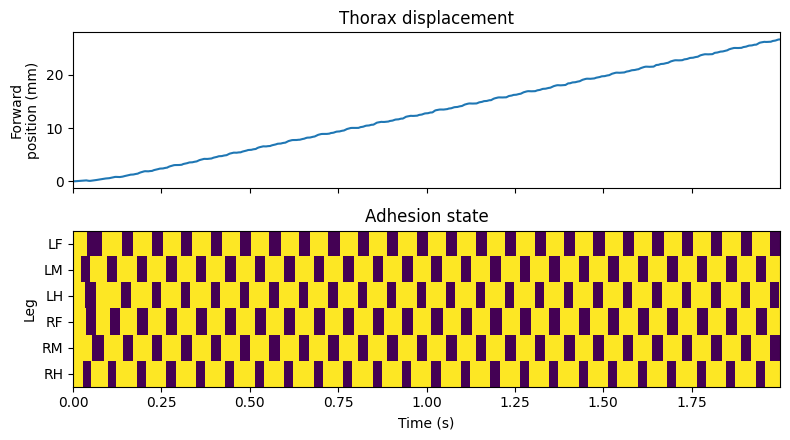

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(8, 4.5), tight_layout=True, sharex=True)

axes[0].plot(time_grid, thorax_positions[:, 0] - thorax_positions[0, 0])
axes[0].set_ylabel("Forward\nposition (mm)")
axes[0].set_title("Thorax displacement")

axes[1].imshow(
    adhesion_onoff.T,
    aspect="auto",
    interpolation="nearest",
    extent=(time_grid[0], time_grid[-1], 5.5, -0.5),
)
axes[1].set_yticks(np.arange(6))
axes[1].set_yticklabels([leg.upper() for leg in preprogrammed_steps.legs])
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Leg")
axes[1].set_title("Adhesion state")

fig.savefig(output_dir / "cpg_controller_diagnostics.png")